# Segmentacion de hogares por consumo electrico

Esta libreta desarrolla un modelo de clustering para segmentar hogares con base en su comportamiento de consumo electrico. El objetivo es comparar configuraciones de K-Means y DBSCAN, documentar la preparacion de variables y dejar todos los artefactos generados en una carpeta propia de salida.

Los outputs de esta libreta se guardan en:

- `output/smart_meters_clustering_consumo/tables`
- `output/smart_meters_clustering_consumo/images`

Con esta organizacion, las tablas y graficas quedan separadas de otros experimentos del proyecto.


# 1. Configuracion general y rutas

Se cargan las librerias, se define una semilla reproducible y se crean las carpetas donde se almacenaran los resultados de la libreta.


In [6]:
from pathlib import Path
import os
import warnings

PROJECT_DIR = Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_DIR / ".matplotlib_cache"))
os.environ.setdefault("XDG_CACHE_HOME", str(PROJECT_DIR / ".cache"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
DATA_PATH = PROJECT_DIR / "data" / "smart_meters_hogar_perfil.csv"
OUTPUT_DIR = PROJECT_DIR / "output" / "smart_meters_clustering_consumo"
TABLES_DIR = OUTPUT_DIR / "tables"
IMAGES_DIR = OUTPUT_DIR / "images"

for directory in [OUTPUT_DIR, TABLES_DIR, IMAGES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Dataset: {DATA_PATH}")
print(f"Tablas:  {TABLES_DIR}")
print(f"Graficas: {IMAGES_DIR}")


Dataset: /Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/data/smart_meters_hogar_perfil.csv
Tablas:  /Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/output/smart_meters_clustering_consumo/tables
Graficas: /Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/output/smart_meters_clustering_consumo/images


# 2. Carga del dataset y revision inicial

Se parte del dataset consolidado por hogar. Cada fila representa un medidor/hogar y contiene variables agregadas de consumo, cobertura temporal y variables categoricas para interpretacion posterior.


In [7]:
df_hogares = pd.read_csv(DATA_PATH)

id_col = "LCLid" if "LCLid" in df_hogares.columns else df_hogares.columns[0]
categoricas_negocio = [col for col in ["stdorToU", "Acorn_grouped"] if col in df_hogares.columns]

serie_tipos = df_hogares.dtypes.astype(str)
df_01_resumen_dataset = pd.DataFrame({
    "metrica": [
        "filas",
        "columnas",
        "hogares_unicos",
        "duplicados_por_hogar",
        "variables_numericas",
        "variables_categoricas_negocio"
    ],
    "valor": [
        len(df_hogares),
        df_hogares.shape[1],
        df_hogares[id_col].nunique(),
        df_hogares.duplicated(subset=[id_col]).sum(),
        int(df_hogares.select_dtypes(include="number").shape[1]),
        ", ".join(categoricas_negocio) if categoricas_negocio else "sin variables categoricas disponibles"
    ]
})

df_01_resumen_dataset.to_csv(TABLES_DIR / "df_01_resumen_dataset.csv", index=False)
display(df_01_resumen_dataset)
display(df_hogares.head())


,metrica,valor
0,filas,5384
1,columnas,15
2,hogares_unicos,5384
3,duplicados_por_hogar,0
4,variables_numericas,12
5,variables_categoricas_negocio,"stdorToU, Acorn_grouped"


,LCLid,consumo_total,consumo_medio,consumo_std,consumo_max,consumo_invierno,consumo_verano,consumo_finde,consumo_semana,ratio_invierno_verano,dias_registrados,stdorToU,Acorn_grouped,tarifa_enc,acorn_enc
0,MAC000002,"6,022.6020",12.0936,4.5174,39.2840,13.2038,9.1410,12.8637,11.7864,1.4445,498,Std,Affluent,0,3
1,MAC000003,"13,949.9560",19.0313,11.6418,50.7590,27.9281,12.2292,18.7917,19.1263,2.2837,733,Std,Adversity,0,2
2,MAC000004,"1,109.9650",1.6946,0.4317,7.3540,1.8376,1.5225,1.7385,1.6772,1.2069,655,Std,Affluent,0,3
3,MAC000005,"2,878.6180",4.5620,1.4734,16.7080,5.5373,3.6761,4.5773,4.5559,1.5063,631,ToU,Affluent,1,3
4,MAC000006,"2,143.4290",2.8427,0.8829,6.6360,2.9856,2.4623,2.7273,2.8885,1.2125,754,Std,Adversity,0,2


# 3. Calidad de datos

Antes de entrenar modelos se revisan valores nulos, duplicados y tipos de dato. Esta etapa permite confirmar si las variables pueden utilizarse directamente o si requieren imputacion/transformacion.


In [8]:
df_02_calidad_columnas = pd.DataFrame({
    "variable": df_hogares.columns,
    "tipo_dato": serie_tipos.values,
    "nulos": df_hogares.isna().sum().values,
    "pct_nulos": (df_hogares.isna().mean().values * 100).round(4),
    "valores_unicos": [df_hogares[col].nunique(dropna=True) for col in df_hogares.columns]
})

df_02_calidad_columnas["uso_preliminar"] = np.where(
    df_02_calidad_columnas["variable"].isin(categoricas_negocio),
    "interpretacion_negocio",
    np.where(df_02_calidad_columnas["tipo_dato"].str.contains("float|int"), "candidata_modelo", "identificador_o_texto")
)

df_02_calidad_columnas.to_csv(TABLES_DIR / "df_02_calidad_columnas.csv", index=False)
display(df_02_calidad_columnas)


,variable,tipo_dato,nulos,pct_nulos,valores_unicos,uso_preliminar
0,LCLid,object,0,0.0000,5384,identificador_o_texto
1,consumo_total,float64,0,0.0000,5384,candidata_modelo
2,consumo_medio,float64,0,0.0000,5384,candidata_modelo
3,consumo_std,float64,0,0.0000,5384,candidata_modelo
4,consumo_max,float64,0,0.0000,5324,candidata_modelo
5,consumo_invierno,float64,0,0.0000,5383,candidata_modelo
6,consumo_verano,float64,0,0.0000,5382,candidata_modelo
7,consumo_finde,float64,0,0.0000,5384,candidata_modelo
8,consumo_semana,float64,0,0.0000,5384,candidata_modelo
9,ratio_invierno_verano,float64,0,0.0000,5384,candidata_modelo


# 4. Seleccion inicial de variables

Las variables numericas seleccionadas describen magnitud, variabilidad, estacionalidad, diferencia semana/fin de semana y cobertura de medicion. Las variables categoricas no se incluyen en el entrenamiento; se reservan para interpretar si los clusters tienen sentido de negocio.


In [9]:
variables_base = [
    "consumo_medio",
    "consumo_std",
    "consumo_max",
    "consumo_invierno",
    "consumo_verano",
    "consumo_finde",
    "consumo_semana",
    "ratio_invierno_verano",
    "dias_registrados",
]
variables_base = [col for col in variables_base if col in df_hogares.columns]

familias_variables = {
    "consumo_medio": "magnitud",
    "consumo_std": "variabilidad",
    "consumo_max": "picos",
    "consumo_invierno": "estacionalidad",
    "consumo_verano": "estacionalidad",
    "consumo_finde": "patron_semanal",
    "consumo_semana": "patron_semanal",
    "ratio_invierno_verano": "estacionalidad_relativa",
    "dias_registrados": "cobertura",
}

df_03_variables_modelo = pd.DataFrame({
    "variable": variables_base,
    "familia": [familias_variables.get(col, "otro") for col in variables_base],
    "tipo_dato": [str(df_hogares[col].dtype) for col in variables_base],
    "nulos": [df_hogares[col].isna().sum() for col in variables_base],
    "pct_nulos": [round(df_hogares[col].isna().mean() * 100, 4) for col in variables_base],
    "uso": "entrada_candidata_clustering"
})

df_03_variables_modelo.to_csv(TABLES_DIR / "df_03_variables_modelo.csv", index=False)
display(df_03_variables_modelo)


,variable,familia,tipo_dato,nulos,pct_nulos,uso
0,consumo_medio,magnitud,float64,0,0.0000,entrada_candidata_clustering
1,consumo_std,variabilidad,float64,0,0.0000,entrada_candidata_clustering
2,consumo_max,picos,float64,0,0.0000,entrada_candidata_clustering
3,consumo_invierno,estacionalidad,float64,0,0.0000,entrada_candidata_clustering
4,consumo_verano,estacionalidad,float64,0,0.0000,entrada_candidata_clustering
5,consumo_finde,patron_semanal,float64,0,0.0000,entrada_candidata_clustering
6,consumo_semana,patron_semanal,float64,0,0.0000,entrada_candidata_clustering
7,ratio_invierno_verano,estacionalidad_relativa,float64,0,0.0000,entrada_candidata_clustering
8,dias_registrados,cobertura,int64,0,0.0000,entrada_candidata_clustering


# 5. Estadistica descriptiva y outliers

Se revisan percentiles y posibles valores extremos. Como las variables de consumo suelen estar sesgadas a la derecha, se aplican transformaciones logaritmicas y recortes controlados en razones antes del escalamiento.


In [10]:
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
resumen = df_hogares[variables_base].describe(percentiles=percentiles).T
resumen = resumen.rename(columns={"50%": "mediana"})
resumen["nulos"] = df_hogares[variables_base].isna().sum()
resumen["pct_nulos"] = df_hogares[variables_base].isna().mean() * 100

df_04_resumen_numerico = resumen.reset_index().rename(columns={"index": "variable"})
df_04_resumen_numerico.to_csv(TABLES_DIR / "df_04_resumen_numerico.csv", index=False)
display(df_04_resumen_numerico)


,variable,count,mean,std,min,1%,5%,25%,mediana,75%,95%,99%,max,nulos,pct_nulos
0,consumo_medio,"5,384.0000",10.1783,7.3278,0.0000,1.5207,2.8499,5.3802,8.3355,12.8136,23.2005,36.9730,101.3670,0,0.0000
1,consumo_std,"5,384.0000",3.8724,3.8846,0.0000,0.4823,0.8288,1.6636,2.7520,4.4930,11.0328,19.7754,61.8069,0,0.0000
2,consumo_max,"5,384.0000",27.0608,22.1287,0.0000,4.1999,6.8432,13.3887,21.3395,33.6810,66.0024,109.8124,332.5560,0,0.0000
3,consumo_invierno,"5,384.0000",12.0309,9.8326,0.0000,1.3939,2.9671,5.9818,9.4296,14.8120,29.8813,51.1052,111.2268,0,0.0000
4,consumo_verano,"5,384.0000",8.2359,5.5005,0.0000,1.3525,2.4603,4.5771,7.0506,10.4092,17.7002,26.8735,87.2816,0,0.0000
5,consumo_finde,"5,384.0000",10.5218,7.4156,0.0000,1.3788,2.8757,5.5314,8.6870,13.3047,24.0050,37.0440,96.8445,0,0.0000
6,consumo_semana,"5,384.0000",10.0416,7.3344,0.0000,1.5099,2.8263,5.2937,8.2150,12.5629,23.1369,36.9489,103.1563,0,0.0000
7,ratio_invierno_verano,"5,384.0000",140.6618,"8,238.3374",0.0000,0.6602,0.9027,1.1115,1.2775,1.5316,2.8188,5.2889,"582,061.1089",0,0.0000
8,dias_registrados,"5,384.0000",636.4155,88.0326,358.0000,405.0000,487.0000,596.0000,646.0000,679.0000,795.0000,815.0000,822.0000,0,0.0000


In [11]:
df_modelo = df_hogares.copy()

variables_log = [
    col for col in [
        "consumo_medio", "consumo_std", "consumo_max", "consumo_invierno",
        "consumo_verano", "consumo_finde", "consumo_semana"
    ] if col in df_modelo.columns
]

for col in variables_log:
    df_modelo[f"log_{col}"] = np.log1p(df_modelo[col].clip(lower=0))

if "ratio_invierno_verano" in df_modelo.columns:
    limite_ratio = df_modelo["ratio_invierno_verano"].quantile(0.99)
    df_modelo["ratio_invierno_verano_clip"] = df_modelo["ratio_invierno_verano"].clip(upper=limite_ratio)

features_modelo = [f"log_{col}" for col in variables_log]
if "ratio_invierno_verano_clip" in df_modelo.columns:
    features_modelo.append("ratio_invierno_verano_clip")
if "dias_registrados" in df_modelo.columns:
    features_modelo.append("dias_registrados")

for col in features_modelo:
    df_modelo[col] = df_modelo[col].replace([np.inf, -np.inf], np.nan)
    if df_modelo[col].isna().any():
        df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())

df_05_variables_transformadas = pd.DataFrame({
    "variable_modelo": features_modelo,
    "origen": [col.replace("log_", "") if col.startswith("log_") else col for col in features_modelo],
    "transformacion": ["log1p" if col.startswith("log_") else "clip_p99_o_directa" for col in features_modelo],
    "nulos_post_tratamiento": [df_modelo[col].isna().sum() for col in features_modelo]
})

df_05_variables_transformadas.to_csv(TABLES_DIR / "df_05_variables_transformadas.csv", index=False)
display(df_05_variables_transformadas)


,variable_modelo,origen,transformacion,nulos_post_tratamiento
0,log_consumo_medio,consumo_medio,log1p,0
1,log_consumo_std,consumo_std,log1p,0
2,log_consumo_max,consumo_max,log1p,0
3,log_consumo_invierno,consumo_invierno,log1p,0
4,log_consumo_verano,consumo_verano,log1p,0
5,log_consumo_finde,consumo_finde,log1p,0
6,log_consumo_semana,consumo_semana,log1p,0
7,ratio_invierno_verano_clip,ratio_invierno_verano_clip,clip_p99_o_directa,0
8,dias_registrados,dias_registrados,clip_p99_o_directa,0


# 6. Matriz de correlacion de variables del modelo

La correlacion Spearman permite identificar redundancia entre variables transformadas. Valores muy altos indican que dos variables aportan informacion parecida; aun asi, en esta etapa se conserva el conjunto completo para comparar su comportamiento en los modelos.


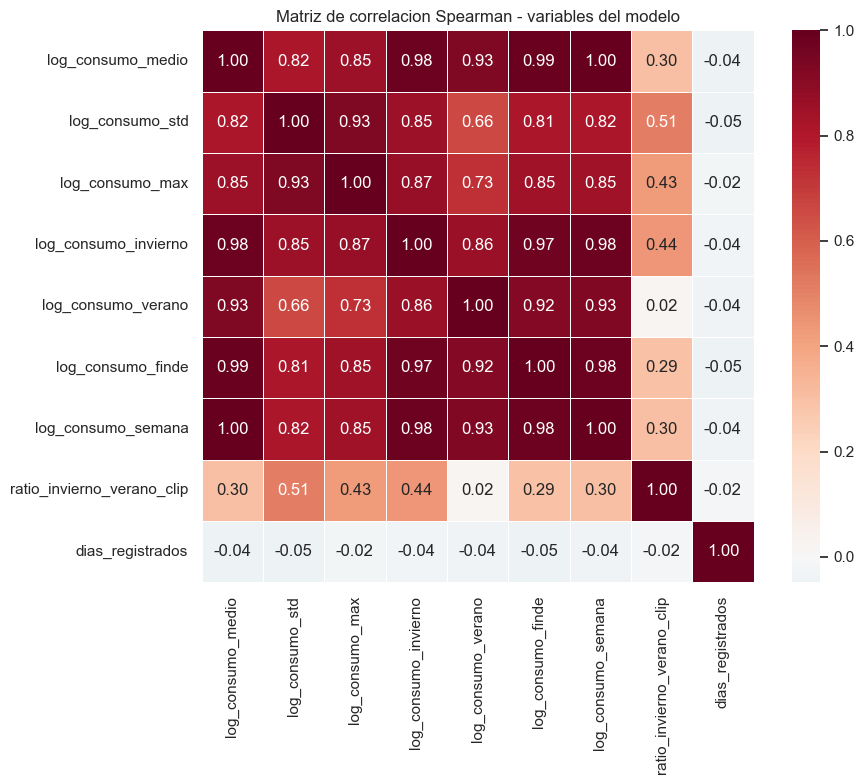

,log_consumo_medio,log_consumo_std,log_consumo_max,log_consumo_invierno,log_consumo_verano,log_consumo_finde,log_consumo_semana,ratio_invierno_verano_clip,dias_registrados
log_consumo_medio,1.0000,0.8195,0.8507,0.9819,0.9287,0.9900,0.9983,0.3011,-0.0450
log_consumo_std,0.8195,1.0000,0.9309,0.8530,0.6639,0.8126,0.8168,0.5102,-0.0472
log_consumo_max,0.8507,0.9309,1.0000,0.8687,0.7295,0.8452,0.8476,0.4273,-0.0235
log_consumo_invierno,0.9819,0.8530,0.8687,1.0000,0.8636,0.9716,0.9803,0.4403,-0.0350
log_consumo_verano,0.9287,0.6639,0.7295,0.8636,1.0000,0.9219,0.9261,0.0209,-0.0387
log_consumo_finde,0.9900,0.8126,0.8452,0.9716,0.9219,1.0000,0.9802,0.2940,-0.0486
log_consumo_semana,0.9983,0.8168,0.8476,0.9803,0.9261,0.9802,1.0000,0.3022,-0.0434
ratio_invierno_verano_clip,0.3011,0.5102,0.4273,0.4403,0.0209,0.2940,0.3022,1.0000,-0.0188
dias_registrados,-0.0450,-0.0472,-0.0235,-0.0350,-0.0387,-0.0486,-0.0434,-0.0188,1.0000


In [12]:
df_06_correlacion_spearman = df_modelo[features_modelo].corr(method="spearman")
df_06_correlacion_spearman.to_csv(TABLES_DIR / "df_06_correlacion_spearman.csv")

plt.figure(figsize=(10, 8))
sns.heatmap(df_06_correlacion_spearman, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=0.4)
plt.title("Matriz de correlacion Spearman - variables del modelo")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "matriz_correlacion_spearman_variables_modelo.png", dpi=160, bbox_inches="tight")
plt.show()

display(df_06_correlacion_spearman)


# 7. Escalamiento

K-Means, PCA y DBSCAN son sensibles a la escala. Por ello, las variables se estandarizan para que cada una tenga media cero y desviacion estandar uno.


In [13]:
X = df_modelo[features_modelo].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_07_escalamiento = pd.DataFrame({
    "variable": features_modelo,
    "media_original": X.mean().values,
    "std_original": X.std(ddof=0).values,
    "media_escalada": X_scaled.mean(axis=0),
    "std_escalada": X_scaled.std(axis=0),
})

df_07_escalamiento.to_csv(TABLES_DIR / "df_07_escalamiento.csv", index=False)
display(df_07_escalamiento)


,variable,media_original,std_original,media_escalada,std_escalada
0,log_consumo_medio,2.2463,0.5734,-0.0000,1.0000
1,log_consumo_std,1.3937,0.5717,-0.0000,1.0000
2,log_consumo_max,3.1123,0.6567,-0.0000,1.0000
3,log_consumo_invierno,2.3602,0.6321,0.0000,1.0000
4,log_consumo_verano,2.0817,0.5296,0.0000,1.0000
5,log_consumo_finde,2.2753,0.5808,-0.0000,1.0000
6,log_consumo_semana,2.2327,0.5736,-0.0000,1.0000
7,ratio_invierno_verano_clip,1.4706,0.7166,0.0000,1.0000
8,dias_registrados,636.4155,88.0244,0.0000,1.0000


# 8. Funciones auxiliares de evaluacion

Se utilizan metricas internas estandar: Silhouette, Davies-Bouldin y Calinski-Harabasz. En DBSCAN tambien se monitorea el porcentaje de ruido, ya que un buen puntaje puede ser poco util si descarta demasiados hogares.


In [14]:
def evaluar_labels(X_eval, labels, modelo, configuracion):
    labels = np.asarray(labels)
    mascara_valida = labels != -1
    labels_validos = labels[mascara_valida]
    X_valid = X_eval[mascara_valida]
    n_clusters = len(set(labels_validos))
    ruido_pct = float((~mascara_valida).mean() * 100)

    if len(labels_validos) > 0:
        cluster_mayor = pd.Series(labels_validos).value_counts(normalize=True).max() * 100
        cluster_menor = pd.Series(labels_validos).value_counts(normalize=True).min() * 100
    else:
        cluster_mayor = np.nan
        cluster_menor = np.nan

    if n_clusters >= 2 and X_valid.shape[0] > n_clusters:
        silhouette = silhouette_score(X_valid, labels_validos)
        davies = davies_bouldin_score(X_valid, labels_validos)
        calinski = calinski_harabasz_score(X_valid, labels_validos)
    else:
        silhouette = np.nan
        davies = np.nan
        calinski = np.nan

    return {
        "modelo": modelo,
        "configuracion": configuracion,
        "n_clusters": n_clusters,
        "ruido_pct": ruido_pct,
        "cluster_mayor_pct_sin_ruido": cluster_mayor,
        "cluster_menor_pct_sin_ruido": cluster_menor,
        "Silhouette": silhouette,
        "Davies_Bouldin": davies,
        "Calinski_Harabasz": calinski,
    }


def graficar_metricas_kmeans(df_metricas, titulo, archivo):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sns.lineplot(data=df_metricas, x="K", y="Inertia", marker="o", ax=axes[0])
    axes[0].set_title("Inercia")
    sns.lineplot(data=df_metricas, x="K", y="Silhouette", marker="o", ax=axes[1])
    axes[1].set_title("Silhouette")
    sns.lineplot(data=df_metricas, x="K", y="Davies_Bouldin", marker="o", ax=axes[2])
    axes[2].set_title("Davies-Bouldin")
    fig.suptitle(titulo)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / archivo, dpi=160, bbox_inches="tight")
    plt.show()


# 9. Evaluacion de K-Means sin PCA

Primero se evalua K-Means directamente sobre las variables transformadas y escaladas. Esta corrida sirve como referencia base antes de reducir dimensionalidad.


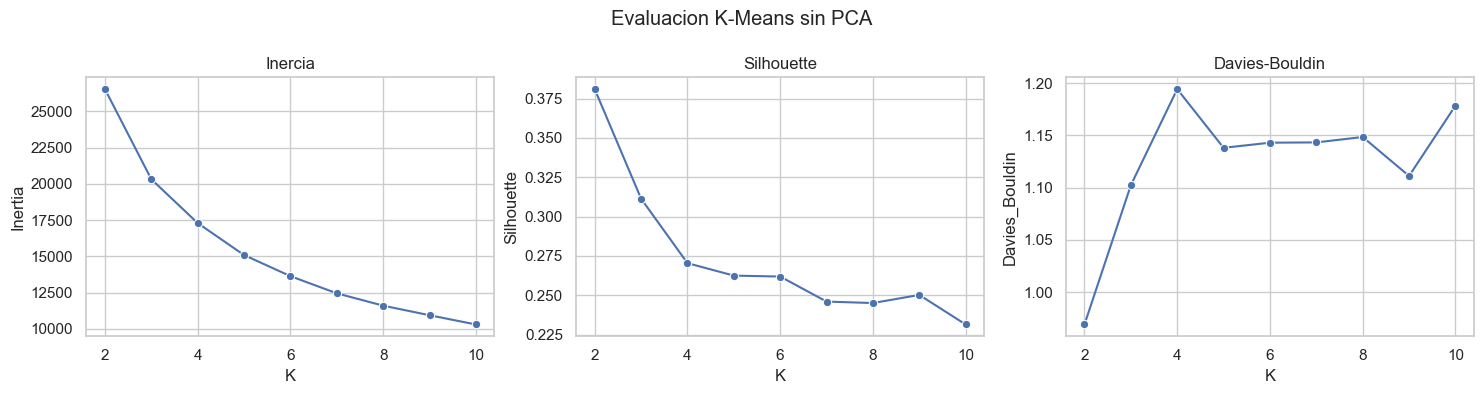

,modelo,configuracion,K,Inertia,n_clusters,ruido_pct,cluster_mayor_pct_sin_ruido,cluster_menor_pct_sin_ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,KMeans_sin_PCA,K=2,2,"26,525.8833",2,0.0000,53.0461,46.9539,0.3810,0.9692,"4,449.5595"
1,KMeans_sin_PCA,K=3,3,"20,316.6473",3,0.0000,46.8982,19.0193,0.3114,1.1023,"3,726.4516"
2,KMeans_sin_PCA,K=4,4,"17,295.1478",4,0.0000,38.4658,9.4911,0.2704,1.1942,"3,231.0742"
3,KMeans_sin_PCA,K=5,5,"15,091.5529",5,0.0000,34.7697,4.6805,0.2625,1.1381,"2,972.9796"
4,KMeans_sin_PCA,K=6,6,"13,636.5566",6,0.0000,29.3648,4.6434,0.2619,1.1430,"2,746.4260"
5,KMeans_sin_PCA,K=7,7,"12,454.7929",7,0.0000,24.8143,4.4948,0.2460,1.1433,"2,590.4150"
6,KMeans_sin_PCA,K=8,8,"11,603.7201",8,0.0000,23.8856,4.3276,0.2451,1.1484,"2,439.0991"
7,KMeans_sin_PCA,K=9,9,"10,944.4567",9,0.0000,23.1055,2.2660,0.2502,1.1112,"2,302.8254"
8,KMeans_sin_PCA,K=10,10,"10,306.8848",10,0.0000,20.4866,2.8232,0.2314,1.1784,"2,210.1030"


In [15]:
resultados_kmeans_sin_pca = []
modelos_kmeans_sin_pca = {}

for k in range(2, 11):
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20, max_iter=300)
    labels = modelo.fit_predict(X_scaled)
    metrica = evaluar_labels(X_scaled, labels, "KMeans_sin_PCA", f"K={k}")
    metrica["K"] = k
    metrica["Inertia"] = modelo.inertia_
    resultados_kmeans_sin_pca.append(metrica)
    modelos_kmeans_sin_pca[k] = modelo

df_09_kmeans_sin_pca = pd.DataFrame(resultados_kmeans_sin_pca)
df_09_kmeans_sin_pca = df_09_kmeans_sin_pca[["modelo", "configuracion", "K", "Inertia", "n_clusters", "ruido_pct", "cluster_mayor_pct_sin_ruido", "cluster_menor_pct_sin_ruido", "Silhouette", "Davies_Bouldin", "Calinski_Harabasz"]]
df_09_kmeans_sin_pca.to_csv(TABLES_DIR / "df_09_kmeans_sin_pca.csv", index=False)

graficar_metricas_kmeans(df_09_kmeans_sin_pca, "Evaluacion K-Means sin PCA", "kmeans_sin_pca_metricas.png")
display(df_09_kmeans_sin_pca)


# 10. Analisis PCA

PCA se utiliza para resumir variables correlacionadas y observar cuanta varianza explican los componentes principales. Para entrenamiento se conserva el numero de componentes necesario para explicar al menos 90% de la varianza.


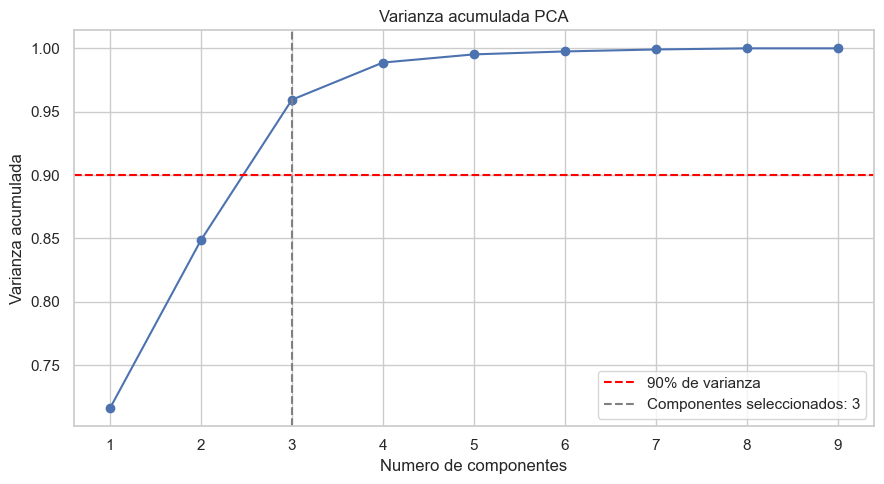

,componente,varianza_explicada,varianza_acumulada
0,1,0.7161,0.7161
1,2,0.1326,0.8487
2,3,0.1108,0.9594
3,4,0.0293,0.9888
4,5,0.0065,0.9952
5,6,0.0023,0.9975
6,7,0.0015,0.9991
7,8,0.0009,1.0000
8,9,0.0000,1.0000


In [16]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
varianza = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza)
n_componentes_90 = int(np.argmax(varianza_acumulada >= 0.90) + 1)
n_componentes_90 = max(2, n_componentes_90)

df_10_pca_varianza = pd.DataFrame({
    "componente": np.arange(1, len(varianza) + 1),
    "varianza_explicada": varianza,
    "varianza_acumulada": varianza_acumulada,
})
df_10_pca_varianza.to_csv(TABLES_DIR / "df_10_pca_varianza.csv", index=False)

plt.figure(figsize=(9, 5))
plt.plot(df_10_pca_varianza["componente"], df_10_pca_varianza["varianza_acumulada"], marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90% de varianza")
plt.axvline(n_componentes_90, color="gray", linestyle="--", label=f"Componentes seleccionados: {n_componentes_90}")
plt.title("Varianza acumulada PCA")
plt.xlabel("Numero de componentes")
plt.ylabel("Varianza acumulada")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / "pca_varianza_acumulada.png", dpi=160, bbox_inches="tight")
plt.show()

pca_modelo = PCA(n_components=n_componentes_90, random_state=RANDOM_STATE)
X_pca = pca_modelo.fit_transform(X_scaled)

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

display(df_10_pca_varianza)


# 11. Evaluacion de K-Means con PCA

Se repite la evaluacion de K-Means usando los componentes principales seleccionados. Esta alternativa puede mejorar la estabilidad al reducir redundancia y ruido entre variables.


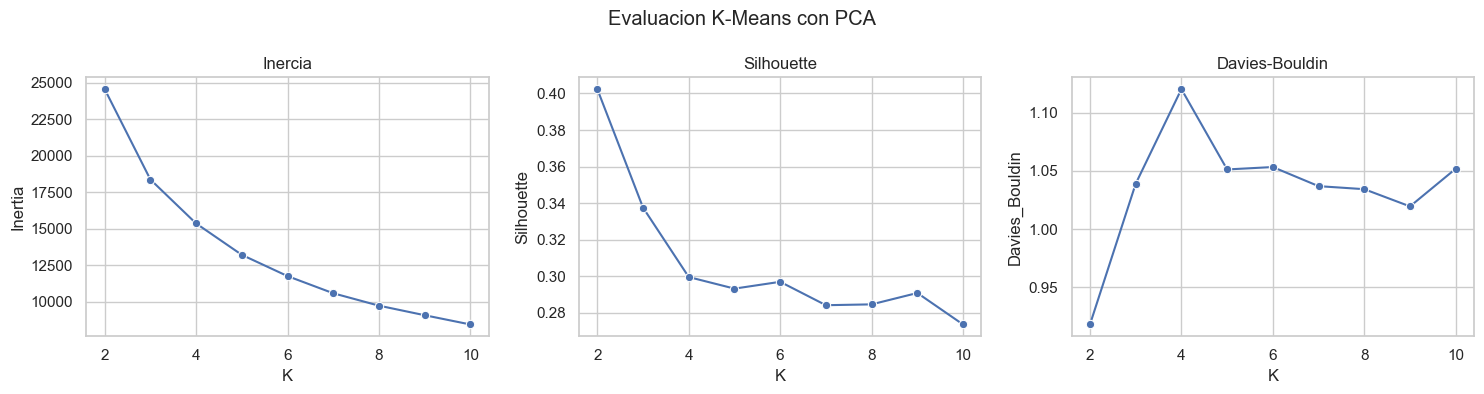

,modelo,configuracion,K,Inertia,n_clusters,ruido_pct,cluster_mayor_pct_sin_ruido,cluster_menor_pct_sin_ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,KMeans_PCA,K=2,2,"24,560.0999",2,0.0000,52.9903,47.0097,0.4024,0.9181,"4,805.5937"
1,KMeans_PCA,K=3,3,"18,366.8599",3,0.0000,46.7868,18.8336,0.3375,1.0389,"4,119.6755"
2,KMeans_PCA,K=4,4,"15,356.8022",4,0.0000,38.4658,9.3053,0.2995,1.1201,"3,635.6799"
3,KMeans_PCA,K=5,5,"13,204.7303",5,0.0000,34.7140,4.7548,0.2932,1.0512,"3,389.6961"
4,KMeans_PCA,K=6,6,"11,749.2184",6,0.0000,29.3648,4.7548,0.2969,1.0532,"3,180.3800"
5,KMeans_PCA,K=7,7,"10,573.2766",7,0.0000,24.7957,4.4391,0.2841,1.0368,"3,044.2277"
6,KMeans_PCA,K=8,8,"9,723.7106",8,0.0000,23.9970,4.3834,0.2846,1.0342,"2,903.8738"
7,KMeans_PCA,K=9,9,"9,068.5302",9,0.0000,23.0869,2.9160,0.2908,1.0194,"2,772.4866"
8,KMeans_PCA,K=10,10,"8,434.7535",10,0.0000,20.6724,2.8418,0.2736,1.0518,"2,693.9801"


In [17]:
resultados_kmeans_pca = []
modelos_kmeans_pca = {}

for k in range(2, 11):
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20, max_iter=300)
    labels = modelo.fit_predict(X_pca)
    metrica = evaluar_labels(X_pca, labels, "KMeans_PCA", f"K={k}")
    metrica["K"] = k
    metrica["Inertia"] = modelo.inertia_
    resultados_kmeans_pca.append(metrica)
    modelos_kmeans_pca[k] = modelo

df_11_kmeans_pca = pd.DataFrame(resultados_kmeans_pca)
df_11_kmeans_pca = df_11_kmeans_pca[["modelo", "configuracion", "K", "Inertia", "n_clusters", "ruido_pct", "cluster_mayor_pct_sin_ruido", "cluster_menor_pct_sin_ruido", "Silhouette", "Davies_Bouldin", "Calinski_Harabasz"]]
df_11_kmeans_pca.to_csv(TABLES_DIR / "df_11_kmeans_pca.csv", index=False)

graficar_metricas_kmeans(df_11_kmeans_pca, "Evaluacion K-Means con PCA", "kmeans_pca_metricas.png")
display(df_11_kmeans_pca)


# 12. Evaluacion exploratoria de DBSCAN

DBSCAN se evalua como contraste porque permite identificar hogares con comportamiento atipico como ruido. La interpretacion debe considerar simultaneamente metricas y porcentaje de ruido.


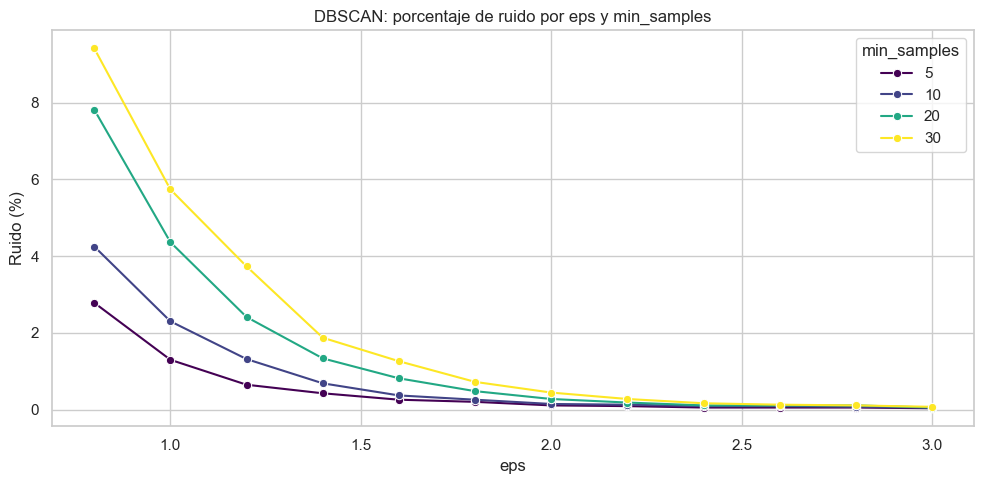

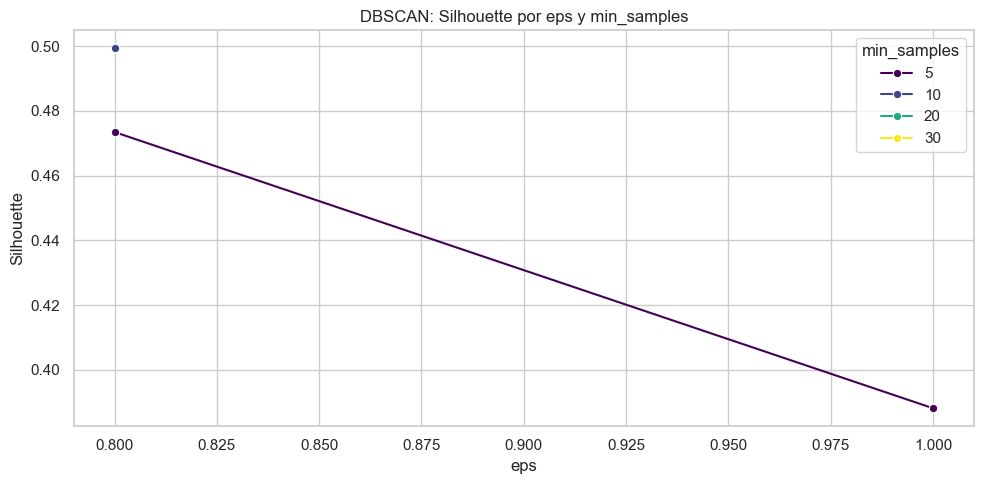

,modelo,configuracion,n_clusters,ruido_pct,cluster_mayor_pct_sin_ruido,cluster_menor_pct_sin_ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz,eps,min_samples
0,DBSCAN_PCA,"eps=0.8, min_samples=10",2,4.2533,99.5926,0.4074,0.4993,0.4758,122.9205,0.8000,10
1,DBSCAN_PCA,"eps=0.8, min_samples=5",3,2.7860,99.8089,0.0955,0.4735,0.4244,34.6581,0.8000,5
2,DBSCAN_PCA,"eps=1.0, min_samples=5",3,1.3001,99.7177,0.1129,0.3882,0.5044,50.9942,1.0000,5
3,DBSCAN_PCA,"eps=0.8, min_samples=20",1,7.8195,100.0000,100.0000,NaN,NaN,NaN,0.8000,20
4,DBSCAN_PCA,"eps=0.8, min_samples=30",1,9.4168,100.0000,100.0000,NaN,NaN,NaN,0.8000,30
5,DBSCAN_PCA,"eps=1.0, min_samples=10",1,2.3031,100.0000,100.0000,NaN,NaN,NaN,1.0000,10
6,DBSCAN_PCA,"eps=1.0, min_samples=20",1,4.3648,100.0000,100.0000,NaN,NaN,NaN,1.0000,20
7,DBSCAN_PCA,"eps=1.0, min_samples=30",1,5.7392,100.0000,100.0000,NaN,NaN,NaN,1.0000,30
8,DBSCAN_PCA,"eps=1.2, min_samples=5",1,0.6501,100.0000,100.0000,NaN,NaN,NaN,1.2000,5
9,DBSCAN_PCA,"eps=1.2, min_samples=10",1,1.3187,100.0000,100.0000,NaN,NaN,NaN,1.2000,10


In [18]:
eps_grid = np.round(np.linspace(0.8, 3.0, 12), 4)
min_samples_grid = [5, 10, 20, 30]
resultados_dbscan = []

for eps in eps_grid:
    for min_samples in min_samples_grid:
        modelo = DBSCAN(eps=float(eps), min_samples=min_samples)
        labels = modelo.fit_predict(X_pca)
        metrica = evaluar_labels(X_pca, labels, "DBSCAN_PCA", f"eps={eps}, min_samples={min_samples}")
        metrica["eps"] = float(eps)
        metrica["min_samples"] = min_samples
        resultados_dbscan.append(metrica)

df_12_dbscan = pd.DataFrame(resultados_dbscan)
df_12_dbscan = df_12_dbscan.sort_values(["Silhouette", "Davies_Bouldin"], ascending=[False, True], na_position="last").reset_index(drop=True)
df_12_dbscan.to_csv(TABLES_DIR / "df_12_dbscan_pca.csv", index=False)

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_12_dbscan, x="eps", y="ruido_pct", hue="min_samples", marker="o", palette="viridis")
plt.title("DBSCAN: porcentaje de ruido por eps y min_samples")
plt.xlabel("eps")
plt.ylabel("Ruido (%)")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "dbscan_ruido_por_parametros.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_12_dbscan, x="eps", y="Silhouette", hue="min_samples", marker="o", palette="viridis")
plt.title("DBSCAN: Silhouette por eps y min_samples")
plt.xlabel("eps")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "dbscan_silhouette_por_parametros.png", dpi=160, bbox_inches="tight")
plt.show()

display(df_12_dbscan.head(15))


# 13. Comparacion de modelos

La comparacion integra los mejores candidatos de K-Means sin PCA, K-Means con PCA y DBSCAN. La decision no debe basarse solo en el puntaje maximo: tambien importan balance, interpretabilidad y utilidad para segmentacion de hogares.


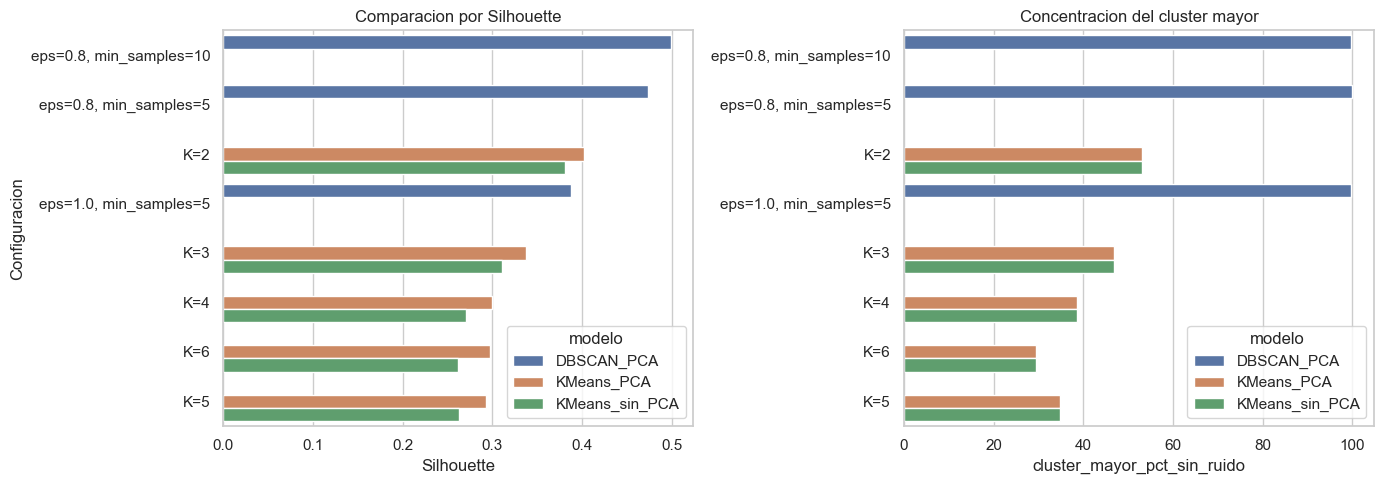

,modelo,configuracion,K,Inertia,n_clusters,ruido_pct,cluster_mayor_pct_sin_ruido,cluster_menor_pct_sin_ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz,eps,min_samples
0,DBSCAN_PCA,"eps=0.8, min_samples=10",NaN,NaN,2,4.2533,99.5926,0.4074,0.4993,0.4758,122.9205,0.8000,10.0000
1,DBSCAN_PCA,"eps=0.8, min_samples=5",NaN,NaN,3,2.7860,99.8089,0.0955,0.4735,0.4244,34.6581,0.8000,5.0000
2,KMeans_PCA,K=2,2.0000,"24,560.0999",2,0.0000,52.9903,47.0097,0.4024,0.9181,"4,805.5937",NaN,NaN
3,DBSCAN_PCA,"eps=1.0, min_samples=5",NaN,NaN,3,1.3001,99.7177,0.1129,0.3882,0.5044,50.9942,1.0000,5.0000
4,KMeans_sin_PCA,K=2,2.0000,"26,525.8833",2,0.0000,53.0461,46.9539,0.3810,0.9692,"4,449.5595",NaN,NaN
5,KMeans_PCA,K=3,3.0000,"18,366.8599",3,0.0000,46.7868,18.8336,0.3375,1.0389,"4,119.6755",NaN,NaN
6,KMeans_sin_PCA,K=3,3.0000,"20,316.6473",3,0.0000,46.8982,19.0193,0.3114,1.1023,"3,726.4516",NaN,NaN
7,KMeans_PCA,K=4,4.0000,"15,356.8022",4,0.0000,38.4658,9.3053,0.2995,1.1201,"3,635.6799",NaN,NaN
8,KMeans_PCA,K=6,6.0000,"11,749.2184",6,0.0000,29.3648,4.7548,0.2969,1.0532,"3,180.3800",NaN,NaN
9,KMeans_PCA,K=5,5.0000,"13,204.7303",5,0.0000,34.7140,4.7548,0.2932,1.0512,"3,389.6961",NaN,NaN


In [19]:
mejores_kmeans_sin_pca = df_09_kmeans_sin_pca.sort_values("Silhouette", ascending=False).head(5)
mejores_kmeans_pca = df_11_kmeans_pca.sort_values("Silhouette", ascending=False).head(5)
mejores_dbscan = df_12_dbscan[df_12_dbscan["n_clusters"] >= 2].sort_values("Silhouette", ascending=False).head(5)

df_13_comparacion_modelos = pd.concat([mejores_kmeans_sin_pca, mejores_kmeans_pca, mejores_dbscan], ignore_index=True, sort=False)
df_13_comparacion_modelos = df_13_comparacion_modelos.sort_values("Silhouette", ascending=False, na_position="last").reset_index(drop=True)
df_13_comparacion_modelos.to_csv(TABLES_DIR / "df_13_comparacion_modelos.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df_13_comparacion_modelos, y="configuracion", x="Silhouette", hue="modelo", ax=axes[0])
axes[0].set_title("Comparacion por Silhouette")
axes[0].set_ylabel("Configuracion")
sns.barplot(data=df_13_comparacion_modelos, y="configuracion", x="cluster_mayor_pct_sin_ruido", hue="modelo", ax=axes[1])
axes[1].set_title("Concentracion del cluster mayor")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "comparacion_modelos_clustering.png", dpi=160, bbox_inches="tight")
plt.show()

display(df_13_comparacion_modelos)


# 14. Decision del modelo seleccionado

Para el cierre academico del proyecto se selecciona K-Means con PCA y K = 3. Esta configuracion mantiene una estructura simple, comparable e interpretable, y evita que la segmentacion dependa de clusters demasiado pequenos o de un porcentaje elevado de ruido.

DBSCAN puede mostrar metricas internas altas en algunas configuraciones, pero su utilidad para campanas es menor cuando concentra casi todos los hogares en un solo cluster o marca una proporcion relevante como ruido. K = 3 permite construir perfiles de consumo accionables y suficientemente diferenciados.


In [20]:
FINAL_K = 3
modelo_final = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=20, max_iter=300)
labels_final = modelo_final.fit_predict(X_pca)

metricas_final = evaluar_labels(X_pca, labels_final, "KMeans_PCA", f"K={FINAL_K}")
metricas_final["Inertia"] = modelo_final.inertia_
metricas_final["componentes_pca"] = n_componentes_90

df_14_decision_modelo = pd.DataFrame([{
    "modelo_seleccionado": "KMeans con PCA",
    "K": FINAL_K,
    "criterio_principal": "equilibrio entre desempeno, interpretabilidad y utilidad de negocio",
    "razon": "K=3 evita una segmentacion excesivamente concentrada y permite construir perfiles accionables de hogares.",
    **metricas_final
}])

df_14_decision_modelo.to_csv(TABLES_DIR / "df_14_decision_modelo.csv", index=False)
display(df_14_decision_modelo)


,modelo_seleccionado,K,criterio_principal,razon,modelo,configuracion,n_clusters,ruido_pct,cluster_mayor_pct_sin_ruido,cluster_menor_pct_sin_ruido,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inertia,componentes_pca
0,KMeans con PCA,3,"equilibrio entre desempeno, interpretabilidad ...",K=3 evita una segmentacion excesivamente conce...,KMeans_PCA,K=3,3,0.0000,46.7868,18.8336,0.3375,1.0389,"4,119.6755","18,366.8599",3


# 15. Entrenamiento final y resultados por hogar

Se entrena el modelo seleccionado y se asigna un cluster a cada hogar. El archivo resultante conserva el identificador, variables numericas clave, variables categoricas de negocio y coordenadas PCA para visualizacion.


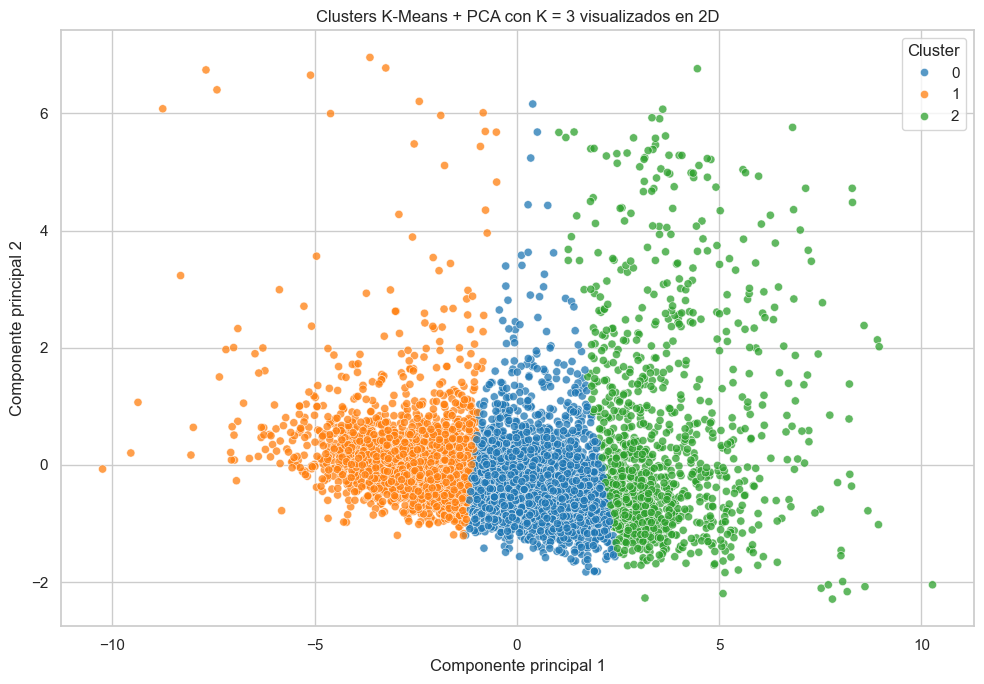

,LCLid,consumo_medio,consumo_std,consumo_max,consumo_invierno,consumo_verano,consumo_finde,consumo_semana,ratio_invierno_verano,dias_registrados,stdorToU,Acorn_grouped,cluster,PC1,PC2
0,MAC000002,12.0936,4.5174,39.2840,13.2038,9.1410,12.8637,11.7864,1.4445,498,Std,Affluent,0,1.5428,-0.2834
1,MAC000003,19.0313,11.6418,50.7590,27.9281,12.2292,18.7917,19.1263,2.2837,733,Std,Adversity,2,3.7632,0.9666
2,MAC000004,1.6946,0.4317,7.3540,1.8376,1.5225,1.7385,1.6772,1.2069,655,Std,Affluent,1,-5.3464,0.6253
3,MAC000005,4.5620,1.4734,16.7080,5.5373,3.6761,4.5773,4.5559,1.5063,631,ToU,Affluent,1,-2.1528,0.4754
4,MAC000006,2.8427,0.8829,6.6360,2.9856,2.4623,2.7273,2.8885,1.2125,754,Std,Adversity,1,-4.1327,0.4144


In [21]:
df_15_hogares_clusterizados = df_hogares[[id_col] + variables_base + categoricas_negocio].copy()
df_15_hogares_clusterizados["cluster"] = labels_final
df_15_hogares_clusterizados["PC1"] = X_pca_2d[:, 0]
df_15_hogares_clusterizados["PC2"] = X_pca_2d[:, 1]

df_15_hogares_clusterizados.to_csv(TABLES_DIR / "df_15_hogares_clusterizados_kmeans_pca_k3.csv", index=False)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_15_hogares_clusterizados, x="PC1", y="PC2", hue="cluster", palette="tab10", s=35, alpha=0.75)
plt.title("Clusters K-Means + PCA con K = 3 visualizados en 2D")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "modelo_final_kmeans_pca_k3_2d.png", dpi=160, bbox_inches="tight")
plt.show()

display(df_15_hogares_clusterizados.head())


# 16. Perfil de clusters

El perfil resume el tamano de cada cluster y las caracteristicas promedio de consumo. Esta tabla es la base para interpretar que tipo de hogares representa cada segmento.


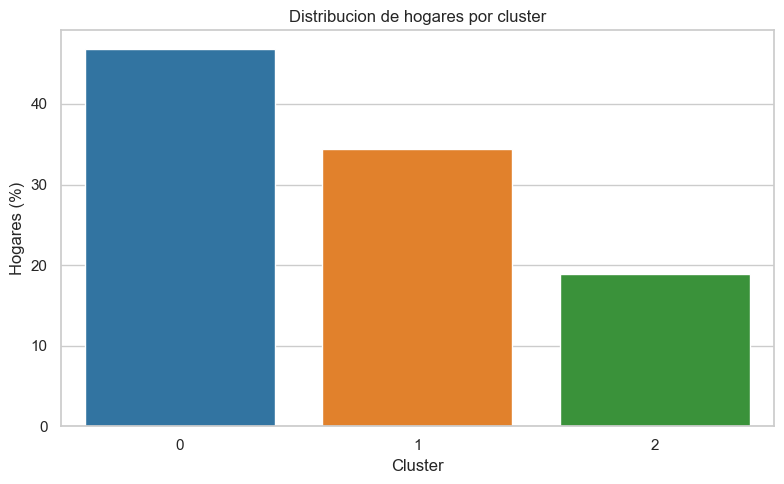

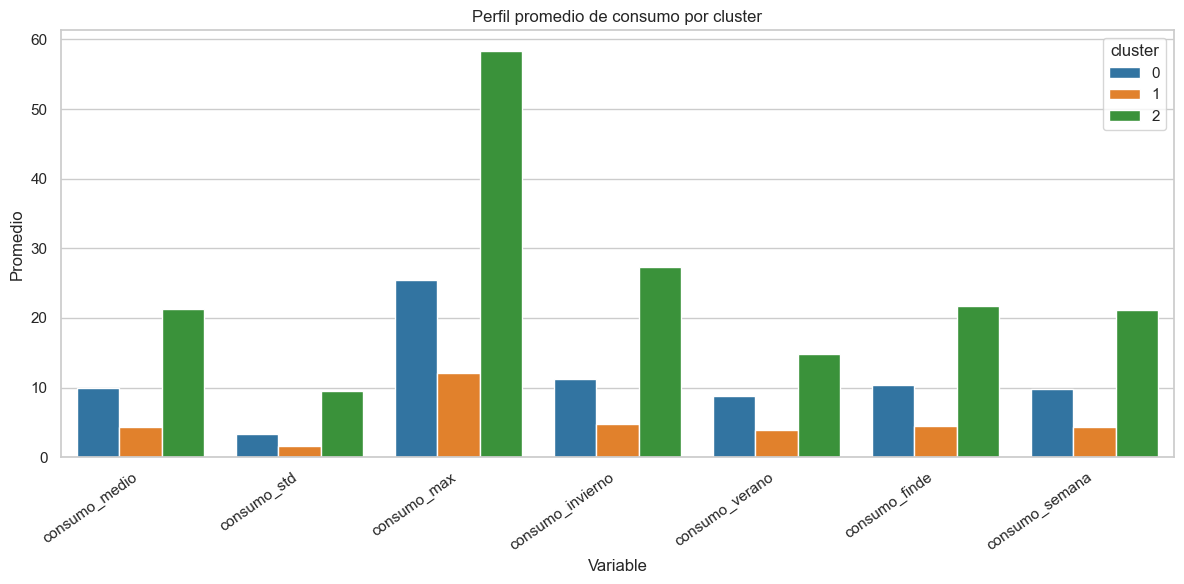

,cluster,hogares,pct_hogares
0,0,2519,46.7868
1,1,1851,34.3796
2,2,1014,18.8336


,cluster,consumo_medio_mean,consumo_medio_median,consumo_medio_std,consumo_std_mean,consumo_std_median,consumo_std_std,consumo_max_mean,consumo_max_median,consumo_max_std,consumo_invierno_mean,consumo_invierno_median,consumo_invierno_std,consumo_verano_mean,consumo_verano_median,consumo_verano_std,consumo_finde_mean,consumo_finde_median,consumo_finde_std,consumo_semana_mean,consumo_semana_median,consumo_semana_std,ratio_invierno_verano_mean,ratio_invierno_verano_median,ratio_invierno_verano_std,dias_registrados_mean,dias_registrados_median,dias_registrados_std
0,0,9.9771,9.5855,2.5426,3.2870,3.1033,1.3098,25.4198,23.9080,9.6893,11.1681,10.7397,2.9174,8.7277,8.3677,2.6184,10.4310,9.9831,2.7848,9.7964,9.3749,2.5261,1.3387,1.2610,0.4323,633.0588,644.0000,89.4166
1,1,4.3837,4.4645,1.4057,1.5614,1.4281,0.8133,12.1428,11.1520,6.1596,4.8196,4.9053,1.6876,3.9427,3.9747,1.3538,4.5276,4.6331,1.5245,4.3264,4.4250,1.3925,406.0297,1.1998,"14,049.0772",642.6926,648.0000,81.1476
2,2,21.2560,18.7125,9.0204,9.5454,7.8767,5.6470,58.3692,49.5280,30.0820,27.3379,23.2406,12.4893,14.8510,13.9930,7.8932,21.6894,19.4694,8.8422,21.0832,18.4155,9.1968,2.3569,1.7219,3.5350,633.2959,642.0000,95.7709


In [22]:
df_16_distribucion_clusters = (
    df_15_hogares_clusterizados["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="hogares")
)
df_16_distribucion_clusters["pct_hogares"] = df_16_distribucion_clusters["hogares"] / len(df_15_hogares_clusterizados) * 100

df_16_perfil_clusters = df_15_hogares_clusterizados.groupby("cluster")[variables_base].agg(["mean", "median", "std"]).reset_index()
df_16_perfil_clusters.columns = ["_".join(col).strip("_") if isinstance(col, tuple) else col for col in df_16_perfil_clusters.columns]

df_16_distribucion_clusters.to_csv(TABLES_DIR / "df_16_distribucion_clusters.csv", index=False)
df_16_perfil_clusters.to_csv(TABLES_DIR / "df_16_perfil_clusters.csv", index=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=df_16_distribucion_clusters, x="cluster", y="pct_hogares", palette="tab10")
plt.title("Distribucion de hogares por cluster")
plt.xlabel("Cluster")
plt.ylabel("Hogares (%)")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "distribucion_clusters_kmeans_pca_k3.png", dpi=160, bbox_inches="tight")
plt.show()

variables_perfil_grafica = [col for col in ["consumo_medio", "consumo_std", "consumo_max", "consumo_invierno", "consumo_verano", "consumo_finde", "consumo_semana"] if col in variables_base]
df_perfil_largo = df_15_hogares_clusterizados.groupby("cluster")[variables_perfil_grafica].mean().reset_index().melt(id_vars="cluster", var_name="variable", value_name="valor_medio")

plt.figure(figsize=(12, 6))
sns.barplot(data=df_perfil_largo, x="variable", y="valor_medio", hue="cluster", palette="tab10")
plt.title("Perfil promedio de consumo por cluster")
plt.xlabel("Variable")
plt.ylabel("Promedio")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "perfil_promedio_clusters_kmeans_pca_k3.png", dpi=160, bbox_inches="tight")
plt.show()

display(df_16_distribucion_clusters)
display(df_16_perfil_clusters)


## Perfilamiento de clusters de magnitud de consumo

### Cluster 0: Consumo medio-alto estable

Este grupo presenta un consumo medio de 9.98, ubicándose por encima del grupo de bajo consumo pero claramente por debajo del grupo de consumo intensivo. Su consumo máximo promedio es de 25.42 y su desviación estándar promedio es de 3.29, lo que sugiere un patrón relativamente estable.

Además, el consumo en invierno es mayor que en verano, con valores promedio de 11.17 frente a 8.73. Esto indica cierta sensibilidad estacional, posiblemente asociada al uso de calefacción, iluminación o mayor permanencia en el hogar durante meses fríos.

Este cluster puede interpretarse como un segmento de **consumo medio-alto estable**.

---

### Cluster 1: Consumo bajo

Este grupo muestra el menor nivel de consumo entre los tres clusters. Su consumo medio promedio es de 4.38, con una mediana de 4.46, lo que indica que la mayoría de los clientes mantienen niveles bajos y consistentes de consumo.

También presenta el menor consumo máximo promedio, con 12.14, y una desviación estándar promedio de 1.56. Esto sugiere consumidores con baja intensidad de uso eléctrico y poca variabilidad.

El consumo de fin de semana y entre semana es muy similar, con promedios de 4.53 y 4.33 respectivamente, por lo que no se observa un cambio fuerte según tipo de día.

Este cluster puede interpretarse como un segmento de **consumo bajo y relativamente estable**.

---

### Cluster 2: Consumo alto / intensivo

Este grupo concentra a los consumidores de mayor intensidad energética. Presenta un consumo medio promedio de 21.26, muy superior al resto de los clusters, y un consumo máximo promedio de 58.37.

También muestra la mayor variabilidad, con una desviación estándar promedio de 9.55, lo que indica que estos clientes no solo consumen más, sino que también presentan cambios más amplios en su comportamiento diario.

El consumo en invierno es considerablemente mayor que en verano, con promedios de 27.34 frente a 14.85. Esto sugiere una fuerte sensibilidad estacional y posible uso intensivo de energía durante meses fríos.

Este cluster puede interpretarse como un segmento de **consumo alto, intensivo y estacional**.

---

## Conclusión

El modelo permite distinguir tres niveles principales de magnitud de consumo:

- **Cluster 1:** Consumo bajo  
- **Cluster 0:** Consumo medio-alto estable  
- **Cluster 2:** Consumo alto / intensivo  

Esta segmentación es útil como primera capa de clasificación del cliente, ya que permite identificar la intensidad general del consumo. Posteriormente, puede combinarse con los perfiles de comportamiento horario, semanal y tipo de consumo para generar etiquetas más completas, por ejemplo:

> Cliente de consumo bajo, nocturno, con mayor actividad en fin de semana y patrón estable.

# 17. Relacion con variables categoricas de negocio

Las variables `Acorn_grouped` y `stdorToU` se usan despues del clustering para interpretar los segmentos. Esto permite validar si los clusters tienen sentido de negocio sin forzar al modelo a agrupar por perfil socioeconomico o tipo de tarifa.


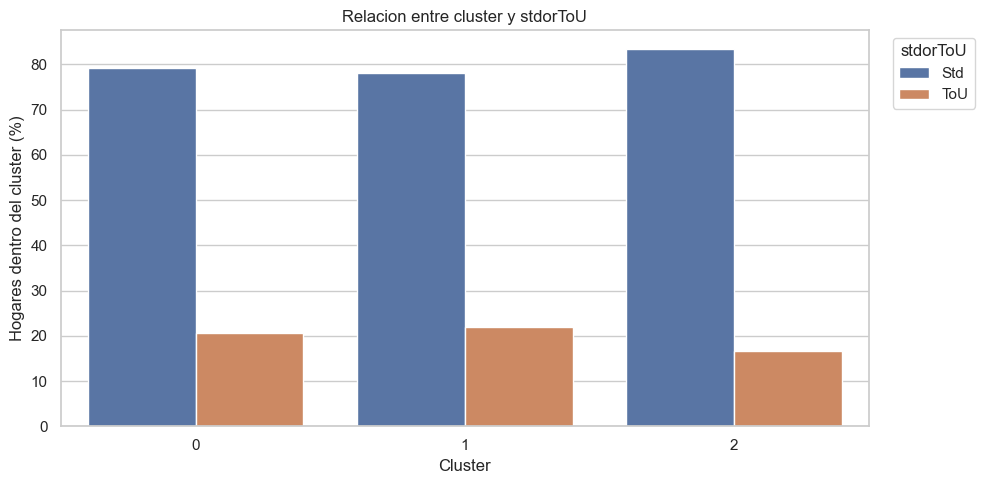

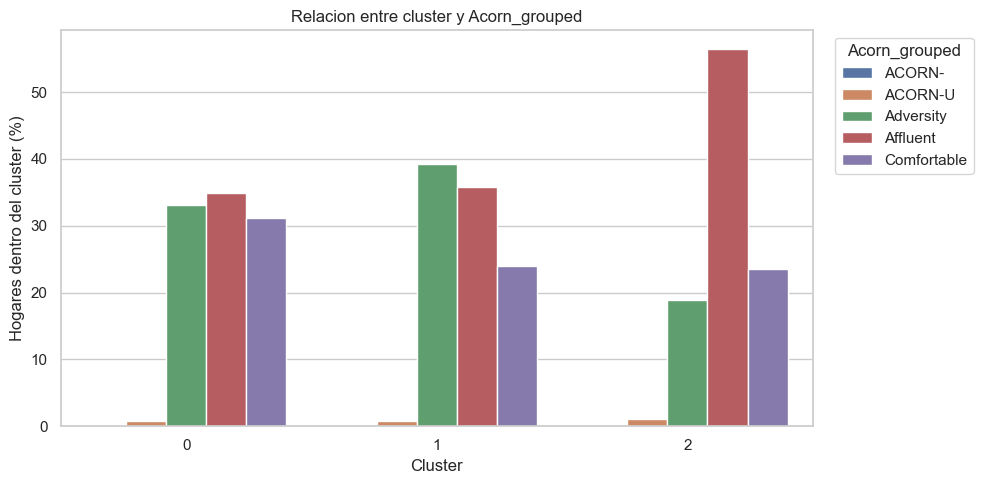

,variable_categorica,cluster,Std,ToU,ACORN-,ACORN-U,Adversity,Affluent,Comfortable
0,stdorToU,0,79.2800,20.7200,NaN,NaN,NaN,NaN,NaN
1,stdorToU,1,78.1700,21.8300,NaN,NaN,NaN,NaN,NaN
2,stdorToU,2,83.3300,16.6700,NaN,NaN,NaN,NaN,NaN
3,Acorn_grouped,0,NaN,NaN,0.0400,0.7500,33.1500,34.8900,31.1600
4,Acorn_grouped,1,NaN,NaN,0.0000,0.8600,39.2800,35.8200,24.0400
5,Acorn_grouped,2,NaN,NaN,0.0000,1.0800,18.9300,56.4100,23.5700


In [23]:
tablas_categoricas = []

for cat in categoricas_negocio:
    tabla = pd.crosstab(df_15_hogares_clusterizados["cluster"], df_15_hogares_clusterizados[cat], normalize="index") * 100
    tabla = tabla.round(2).reset_index()
    tabla.insert(0, "variable_categorica", cat)
    tablas_categoricas.append(tabla)

    tabla_larga = tabla.melt(id_vars=["variable_categorica", "cluster"], var_name="categoria", value_name="pct_hogares")
    plt.figure(figsize=(10, 5))
    sns.barplot(data=tabla_larga, x="cluster", y="pct_hogares", hue="categoria")
    plt.title(f"Relacion entre cluster y {cat}")
    plt.xlabel("Cluster")
    plt.ylabel("Hogares dentro del cluster (%)")
    plt.legend(title=cat, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f"relacion_cluster_{cat}.png", dpi=160, bbox_inches="tight")
    plt.show()

if tablas_categoricas:
    df_17_relacion_categorica = pd.concat(tablas_categoricas, ignore_index=True, sort=False)
else:
    df_17_relacion_categorica = pd.DataFrame({"mensaje": ["No hay variables categoricas de negocio disponibles."]})

df_17_relacion_categorica.to_csv(TABLES_DIR / "df_17_relacion_categorica.csv", index=False)
display(df_17_relacion_categorica)


# 18. Cluster de consumo por casa y cruce con comportamiento

Después de interpretar la relación categórica, se construye un DataFrame operativo con la clasificación final de consumo por hogar. Posteriormente se cruza con el DataFrame de comportamiento generado en la libreta `smart_meters_clustering_comportamiento_final.ipynb` para integrar en una sola tabla la segmentación de consumo y las tres dimensiones de comportamiento.


In [25]:
COMPORTAMIENTO_CLUSTER_PATH = Path("./output/clustering_comportamiento_final/tables/DF_Comportamiento_cluster.csv")

if not COMPORTAMIENTO_CLUSTER_PATH.exists():
    raise FileNotFoundError(f"No se encontró el DataFrame de comportamiento: {COMPORTAMIENTO_CLUSTER_PATH}")

# DataFrame solicitado: clasificación de cluster 0, 1 o 2 por casa para el modelo de consumo.
df_18_cluster_consumo_por_casa = (
    df_15_hogares_clusterizados[[id_col, "cluster"]]
    .rename(columns={id_col: "casa", "cluster": "cluster_consumo"})
    .copy()
)
df_18_cluster_consumo_por_casa["cluster_consumo"] = df_18_cluster_consumo_por_casa["cluster_consumo"].astype(int)

# DataFrame de comportamiento construido en la libreta de comportamiento final.
df_comportamiento_cluster = pd.read_csv(COMPORTAMIENTO_CLUSTER_PATH)

# Merge final: se conservan todas las casas del clustering de consumo.
df_18_consumo_comportamiento_merge = df_18_cluster_consumo_por_casa.merge(
    df_comportamiento_cluster,
    on="casa",
    how="left",
    validate="one_to_one"
)

df_18_validacion_merge = pd.DataFrame({
    "metrica": [
        "casas_cluster_consumo",
        "casas_comportamiento",
        "casas_merge_final",
        "casas_sin_match_comportamiento",
        "clusters_consumo_disponibles"
    ],
    "valor": [
        len(df_18_cluster_consumo_por_casa),
        len(df_comportamiento_cluster),
        len(df_18_consumo_comportamiento_merge),
        df_18_consumo_comportamiento_merge["horario_consumo"].isna().sum() if "horario_consumo" in df_18_consumo_comportamiento_merge.columns else np.nan,
        sorted(df_18_cluster_consumo_por_casa["cluster_consumo"].unique().tolist())
    ]
})

df_18_cluster_consumo_por_casa.to_csv(TABLES_DIR / "df_18_cluster_consumo_por_casa.csv", index=False)
df_18_consumo_comportamiento_merge.to_csv(TABLES_DIR / "df_18_consumo_comportamiento_merge.csv", index=False)
df_18_validacion_merge.to_csv(TABLES_DIR / "df_18_validacion_merge.csv", index=False)

print("Shape df_18_cluster_consumo_por_casa:", df_18_cluster_consumo_por_casa.shape)
print("Shape df_18_consumo_comportamiento_merge:", df_18_consumo_comportamiento_merge.shape)

display(df_18_cluster_consumo_por_casa.head())
display(df_18_consumo_comportamiento_merge.head())
display(df_18_validacion_merge)


Shape df_18_cluster_consumo_por_casa: (5384, 2)
Shape df_18_consumo_comportamiento_merge: (5384, 5)


,casa,cluster_consumo
0,MAC000002,0
1,MAC000003,2
2,MAC000004,1
3,MAC000005,1
4,MAC000006,1


,casa,cluster_consumo,horario_consumo,semanal,tipo_consumo
0,MAC000002,0,consumo_noche_variable,consumo_fin_semana_variable,picos_bajos_variabilidad_baja
1,MAC000003,2,consumo_madrugada_variable,consumo_fin_semana_estable,picos_moderados_variabilidad_media
2,MAC000004,1,consumo_tarde_estable,consumo_fin_semana_estable,picos_moderados_variabilidad_media
3,MAC000005,1,consumo_noche_variable,consumo_fin_semana_estable,picos_bajos_variabilidad_baja
4,MAC000006,1,consumo_tarde_estable,consumo_fin_semana_estable,picos_moderados_variabilidad_media


,metrica,valor
0,casas_cluster_consumo,5384
1,casas_comportamiento,5560
2,casas_merge_final,5384
3,casas_sin_match_comportamiento,0
4,clusters_consumo_disponibles,"[0, 1, 2]"
